In [19]:
import numpy as np
import pandas as pd
import txtpreprocess as txtp
from pathlib import Path
import ast
import random

import yaml
from pathlib import Path
import txtpreprocess as txtp
import argparse

In [24]:
parser = argparse.ArgumentParser(description="")
parser.add_argument("config_file",type = str
                    ,help = "YAML configuration file")
parser.add_argument("task", type = str
                    ,choices = ["count","score"]
                    ,help = "Whether to count number of lines per doc or score the sentences.")
parser.add_argument("--transcript_file_list","-t"
                    ,help = "If not specified in config file, a .csv type file with a column named 'file' containing the list of file names to score")

args = parser.parse_args(['/home/hereinlies/Documents/Documents/Ecole/HEC/ProjetSupervise/data/Configs/Blocked01/config_base_block01.yaml','count','-t','/home/hereinlies/Documents/Documents/Ecole/HEC/ProjetSupervise/data/Configs/Base/model.csv'])


In [25]:
## YAML config loading ##
with open(args.config_file) as f:
    config = yaml.safe_load(f)


## Setting up variables ##
task = args.task
text_folder = config["text_folder"]
preprocessing_steps = config["preprocessing_steps"]

if "transcript_file_list" in config.keys():
    if args.transcript_file_list:
        raise NameError("transcript_file_list cannot both specified in config file and as argument.")
    else:
        transcript_file_list = str(Path(config["config_folder"],config["transcript_file_list"]))
else:
    transcript_file_list = args.transcript_file_list

################
## Main part ##
################

#setup extra vars
extractor = txtp.TextExtraction(preprocessing_steps)

#count and allocation task
if task == "count":
    myallocator = txtp.Allocator(transcript_file_list,text_folder,extractor)
    myallocator.allocate(config["nallocate"])
    myallocator.write_allocation(config)

# older

In [2]:
task = "count"
text_folder = '/home/hereinlies/Downloads/Text'
preprocessing_steps = ["m01"]
transcript_folder = '/home/hereinlies/Downloads/Models'
transcript_file = 'files_block_0.csv'
config = {"text_folder":text_folder,"transcript_folder":transcript_folder, "transcript_file": transcript_file,"preprocessing_steps":preprocessing_steps}
transcript_file = str(Path(config["transcript_folder"],config["transcript_file"]))
extractor = txtp.TextExtraction(preprocessing_steps)

In [3]:
participant_info = pd.read_csv(transcript_file)
participant_info["code"] = participant_info['code'].apply(ast.literal_eval)

In [5]:
ffile, fspeaker, fsentence, fcode = extractor.serial_clean(participant_info, text_folder)

In [23]:
filtidx = [ii for ii, (ss , cc) in enumerate(zip(fspeaker,fcode)) if ss in cc]

In [41]:
all_len = random.sample(range(0, len(fspeaker)), len(fspeaker))

In [78]:
pp= participant_info["file"].iloc[0]
code_list = participant_info["code"].iloc[0]
fext = ".flo.cex"
filepath = str(Path(text_folder,pp).with_suffix(fext))

temp = extractor.single_preprocess("clean",filepath, code_list)

In [69]:
all_len = [len(ss) for ss in fsentence]
slen = [all_len[ii] for ii in filtidx]
order = list(np.argsort(slen))

In [72]:
res = list(map(filtidx.__getitem__, order))

NameError: name 'tokenizer' is not defined

2# Visualization stuff

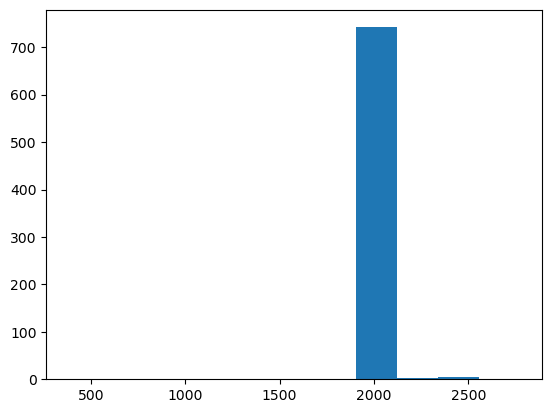

In [6]:
import matplotlib.pyplot as plt

plt.hist(binweight, bins='auto')  # arguments are passed to np.histogram
plt.show()


In [13]:
np.histogram(binweight, bins='auto')

(array([  1,   0,   0,   0,   0,   0,   0, 742,   3,   4,   1]),
 array([ 383.        ,  600.27272727,  817.54545455, 1034.81818182,
        1252.09090909, 1469.36363636, 1686.63636364, 1903.90909091,
        2121.18181818, 2338.45454545, 2555.72727273, 2773.        ]))